In [4]:
import networkx as nx
import matplotlib.pyplot as plt

In [29]:
queries = {
    "Simple Keyword Queries": ['mercy', 'prayer'],
    "Phrase / Exact Match Queries": ['The Lord is my shepherd', 'Create in me a clean heart'],
    "Thematic / Semantic Queries": ['protection from enemies', 'praise in times of suffering'],
    "Long / Complex Queries": [
        'How does the psalmist express trust in God while surrounded by fear and uncertainty?',
        'Verses where the psalmist remembers past deliverance and uses it to find hope in present trials.'
    ],
    "Orthodox Service Quotes": [
        'Have mercy on me, O God, have mercy on me. For my soul trusts in Thee, and in the shadow of Thy wings will I hope, until iniquity pass away.',
        'For the Peace of the world',
        'Rejoice, O ye heavens, sound the trumpets, ye foundation of the earth, thunder forth gladness, O ye mountains: for behold, Emmanuel to the Cross our sins, and the Giver of Life hath slain death, raising up Adam; for He loveth mankind.'
    ]
}

In [ ]:
queries = {
    "Simple Keyword Queries": ['mercy', 'prayer'],
    "Phrase / Exact Match Queries": ['The Lord is my shepherd', 'Create in me a clean heart'],
    "Thematic / Semantic Queries": ['protection from enemies', 'praise in times of suffering'],
    "Long / Complex Queries": [
        'How does the psalmist express trust in God while surrounded by fear and uncertainty?',
        'Verses where the psalmist remembers past deliverance and uses it to find hope in present trials.'
    ],
    "Orthodox Service Quotes": [
        'Have mercy on me, O God, have mercy on me. For my soul trusts in Thee, and in the shadow of Thy wings will I hope, until iniquity pass away.',
        'For the Peace of the world',
        'Rejoice, O ye heavens, sound the trumpets, ye foundation of the earth, thunder forth gladness, O ye mountains: for behold, Emmanuel to the Cross our sins, and the Giver of Life hath slain death, raising up Adam; for He loveth mankind.'
    ]
}

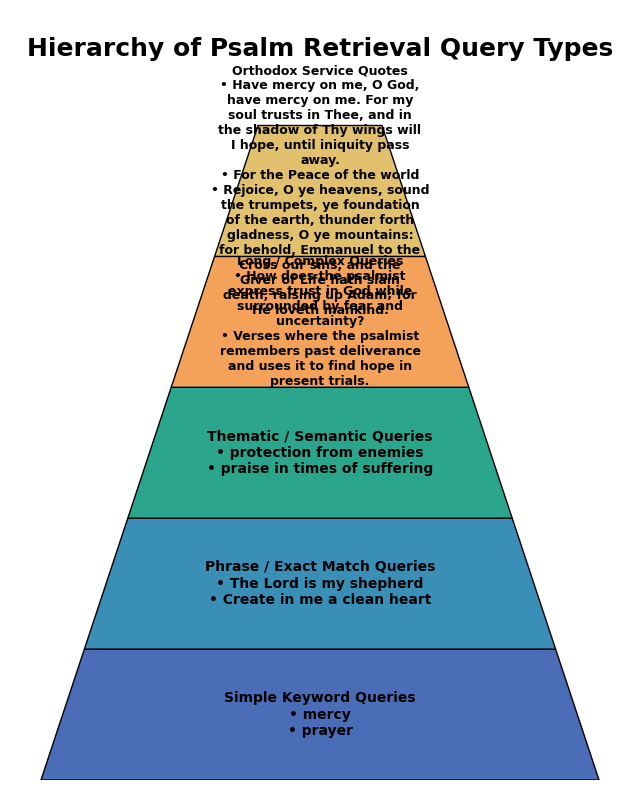

In [30]:
# Order from bottom -> top
levels = list(queries.keys())

# Color palette (dark → gold Orthodox style gradient)
colors = ["#4B6CB7", "#3A8FB7", "#2CA58D", "#F4A259", "#E1C16E"]

# ---------------- FIGURE ----------------
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

height = 1.7
base_width = 9
center = 5

for i, level in enumerate(levels):
    width = base_width - i * 1.4
    y = i * height

    polygon = Polygon([
        (center - width/2, y),
        (center + width/2, y),
        (center + (width-1.4)/2, y + height),
        (center - (width-1.4)/2, y + height)
    ], closed=True, color=colors[i], ec="black")

    ax.add_patch(polygon)

    # Prepare wrapped text
    examples = "\n".join(
        ["• " + textwrap.fill(q, 28) for q in queries[level]]
    )

    text = f"{level}\n{examples}"

    ax.text(center, y + height/2,
            text,
            ha='center', va='center',
            fontsize=10 if i < 3 else 9,
            color="black",
            fontweight="bold")

# Title
ax.text(5, 9.4,
        "Hierarchy of Psalm Retrieval Query Types",
        ha='center', fontsize=18, fontweight='bold')

plt.savefig("query_hierarchy_pyramid.png", dpi=300, bbox_inches='tight')
plt.show()

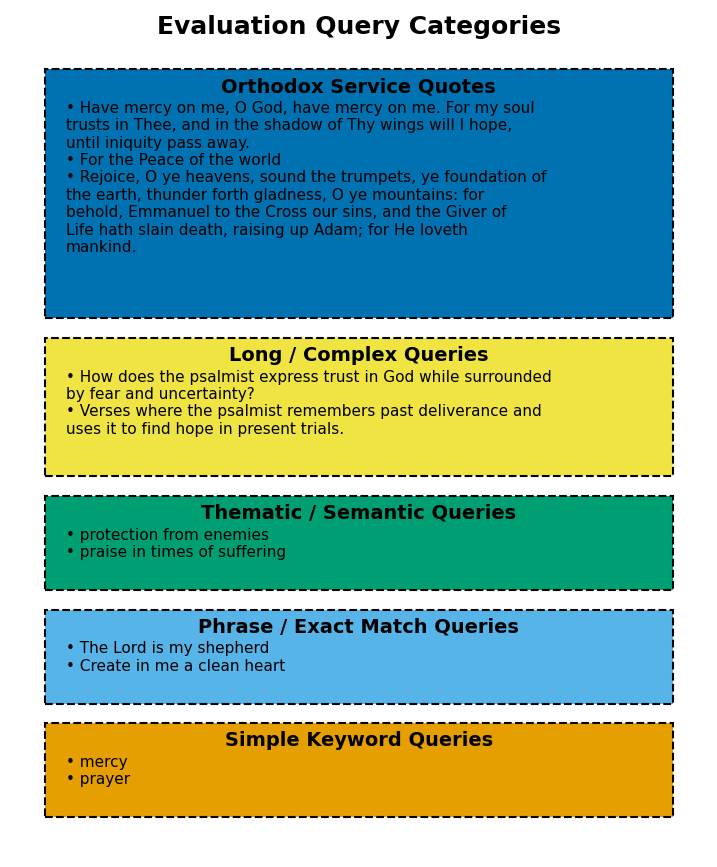

In [63]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import textwrap

# Color-blind friendly colors (optional)
colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2"]

fig, ax = plt.subplots(figsize=(9,11))
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.axis('off')

y = 0.5
rect_width = 9
line_height = 0.28    # proper spacing per line
padding_top = 0.35     # top padding inside rectangle
y_spacing = 0.25       # space between rectangles

for i, (level, items) in enumerate(queries.items()):

    # wrap each query to max line width and add bullet points
    wrapped = "\n".join(["• "+textwrap.fill(q, 60) for q in items])  # extra \n for spacing

    # combine heading + wrapped text
    text = f"{level}\n{wrapped}"

    # calculate dynamic height based on number of lines
    lines = text.split("\n")
    num_lines = len(lines)
    box_height = num_lines * line_height + padding_top

    # draw rectangle
    rect_left = 5 - rect_width/2
    rect = Rectangle((rect_left, y), rect_width, box_height,
                     facecolor=colors[i % len(colors)],
                     edgecolor='black',
                     linewidth=1.5,
                     linestyle='--')
    ax.add_patch(rect)

    # Heading — centered at top of rectangle
    ax.text(5, y + box_height - 0.1, level,
            ha='center', va='top',
            fontsize=14, fontweight='bold')

    # Bullets — left-aligned with padding
    ax.text(rect_left + 0.3, y + box_height - 0.4, wrapped,
            ha='left', va='top',
            fontsize=11)

    # move y-position for next box
    y += box_height + y_spacing

# adjust y-axis to fit all boxes
ax.set_ylim(0, y + 0.5)

# title above boxes
ax.text(5, y + 0.2, "Evaluation Query Categories",
        ha='center', fontsize=18, fontweight='bold')

# save figure
plt.savefig("query_rectangles_fixed.png", dpi=300, bbox_inches='tight')
plt.show()

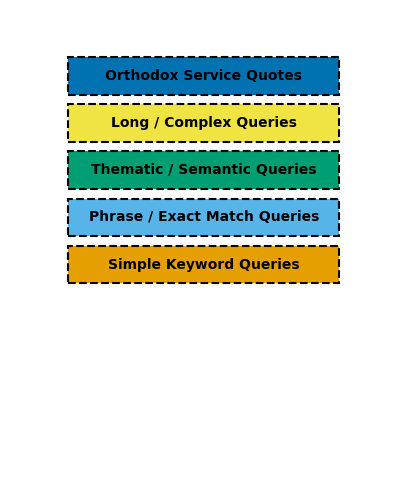

In [64]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------------- COLORS & FIGURE ----------------
colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2"]

fig, ax = plt.subplots(figsize=(5,6))
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.axis('off')

y = 0.5
rect_width = 7

# ---------------- ONLY QUERY CATEGORIES ----------------
for i, category in enumerate(queries.keys()):
    
    # approximate rectangle height for just the heading
    box_height = 0.1  # single line box with some padding

    # draw rectangle
    rect = Rectangle((5 - rect_width/2, y), rect_width, box_height,
                     facecolor=colors[i],
                     edgecolor='black',
                     linewidth=1.5,
                     linestyle='--')
    ax.add_patch(rect)

    # place category text in the middle of rectangle
    ax.text(5, y + box_height/2, category,
            ha='center', va='center',
            fontsize=10, fontweight='bold')

    # increment y for next box
    y += box_height + 0.025

# expand y-axis so all boxes fit
ax.set_ylim(0, y + 0.1)
'''
# add overall title above boxes
ax.text(5, y + 0.2, "Evaluation Query Categories",
        ha='center', fontsize=18, fontweight='bold')'''

# save figure
plt.savefig("query_categories_only.png", dpi=300, bbox_inches='tight')
plt.show()

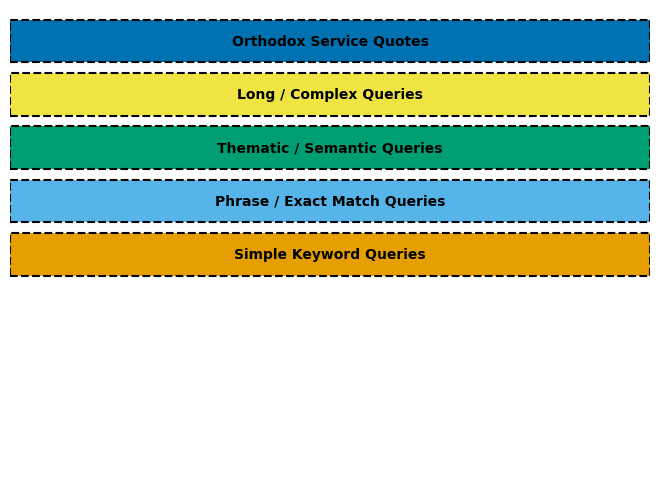

In [68]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------------- COLORS & FIGURE ----------------
colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2"]

# Create figure
fig, ax = plt.subplots()
ax.axis('off')  # remove axes

# Transparent background
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

y = 0.5
rect_width = 4

# ---------------- ONLY QUERY CATEGORIES ----------------
for i, category in enumerate(queries.keys()):
    box_height = 0.1  # height of rectangle

    # Draw rectangle
    rect = Rectangle((0, y), rect_width, box_height,
                     facecolor=colors[i % len(colors)],
                     edgecolor='black',
                     linewidth=1.5,
                     linestyle='--')
    ax.add_patch(rect)

    # Add category text
    ax.text(rect_width/2, y + box_height/2, category,
            ha='center', va='center',
            fontsize=10, fontweight='bold')

    y += box_height + 0.025  # next rectangle

# Set limits to just fit the content
ax.set_xlim(0, rect_width)
ax.set_ylim(0, y)  # y already includes all rectangles and spacing

# Remove extra padding around the figure
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Save figure tightly cropped
plt.savefig(
    "query_categories_only_cropped.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0,
    transparent=True
)

plt.show()